# C-Grain Reverse Model — الإصدار الصحيح النهائي

## سبب المشكلة (مكتشف بالتحليل الفعلي لملفات الـ test)

الـ `ISP (s)` في الـ training CSV محسوب من الـ simulation الداخلي — محتاج **propellant mass** أو **mass flow rate** اللي مش موجودين في ملفات الـ test.

لما دالة الـ inference بتحاول تحسب ISP من المنحنى بدل ما تجده كـ column:
```
isp = mean(thrust) / (mean(pressure) * 9.81)
206_0.xlsx  → ISP = 6.72  s  (z-score = -39) ← ده سبب الكارثة
c_test.csv  → ISP = 42.73 s  (z-score = -31)
Training    → ISP mean = 173 s
```

**الحل:** احذف ISP من الـ scalars. استخدم 5 scalars فقط من columns موجودة دايماً:
`Max Thrust`, `Avg Thrust`, `Total Impulse`, `Peak Pressure`, `Burn Time`

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# ============================================================
# Boundaries الفيزيائية
# ============================================================
BOUNDARIES = {
    'Length':          (20.0, 120.0),
    'Diameter':        (6.0,  20.0),
    'Slot_Width':      (0.5,  4.0),
    'Slot_Offset':     (1.0,  7.0),
    'Throat_Diameter': (0.8,  2.0),
    'Exit_Diameter':   (1.2,  3.0),
}
BOUNDS_MIN = np.array([v[0] for v in BOUNDARIES.values()], dtype=np.float32)
BOUNDS_MAX = np.array([v[1] for v in BOUNDARIES.values()], dtype=np.float32)
DIM_NAMES  = list(BOUNDARIES.keys())

# ============================================================
# 5 Scalars فقط — كلها موجودة في الـ training CSV وقابلة
# للحساب من أي ملف test بدون محتاج mass flow
# ============================================================
SCALAR_COLS = [
    'Max Thrust (N)',
    'Avg Thrust (N)',
    'Total Impulse (Ns)',
    'Peak Pressure (MPa)',
    'Burn Time (s)',
]
N_SCALARS = len(SCALAR_COLS)  # 5

print('TensorFlow:', tf.__version__)
print(f'Scalars ({N_SCALARS}):', SCALAR_COLS)

2026-05-12 10:53:04.203010: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778583184.603966      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778583184.716870      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778583185.748595      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778583185.748621      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778583185.748624      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Scalars (5): ['Max Thrust (N)', 'Avg Thrust (N)', 'Total Impulse (Ns)', 'Peak Pressure (MPa)', 'Burn Time (s)']


## Cell 1 — تحميل البيانات

In [3]:
def process_data(file_path, num_points=200):
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()
    df['ID'] = pd.to_numeric(df['ID'], errors='coerce')
    ids = df['ID'].dropna().unique()

    dim_cols = ['Length', 'Diameter', 'Slot_Width', 'Slot_Offset',
                'Throat_Diameter', 'Exit_Diameter']

    X_curves, X_scalars, Y_dims = [], [], []
    skipped = 0

    for uid in ids:
        try:
            cd   = df[df['ID'] == uid].sort_values('Time (s)').reset_index(drop=True)
            dims = cd[dim_cols].iloc[0].values.astype(float)
            t    = cd['Time (s)'].values.astype(float)

            if len(t) < 10 or t[-1] <= 0 or np.any(dims <= 0):
                skipped += 1; continue
            if np.any(dims < BOUNDS_MIN) or np.any(dims > BOUNDS_MAX):
                skipped += 1; continue

            thrust   = cd['Thrust (N)'].fillna(0).values.astype(float)
            pressure = cd['Pressure (MPa)'].fillna(0).values.astype(float)

            wl = min(7, len(thrust) if len(thrust) % 2 == 1 else len(thrust) - 1)
            if len(thrust) > wl:
                thrust   = savgol_filter(thrust,   window_length=wl, polyorder=3)
                pressure = savgol_filter(pressure, window_length=wl, polyorder=3)

            # Interpolate → 200 points
            x_new = np.linspace(t[0], t[-1], num_points)
            t_i = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
            p_i = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

            # Per-sample normalization
            t_i = t_i / (np.max(np.abs(t_i)) + 1e-8)
            p_i = p_i / (np.max(np.abs(p_i)) + 1e-8)

            # 2-channel: (200, 2)
            curve = np.stack([t_i, p_i], axis=-1)

            # 5 scalars من الـ CSV — بدون ISP
            scalars = cd[SCALAR_COLS].iloc[0].values.astype(float)

            X_curves.append(curve)
            X_scalars.append(scalars)
            Y_dims.append(dims)

        except Exception:
            skipped += 1; continue

    print(f'Loaded : {len(Y_dims):,} | Skipped: {skipped}')
    return (
        np.array(X_curves,  dtype=np.float32),
        np.array(X_scalars, dtype=np.float32),
        np.array(Y_dims,    dtype=np.float32)
    )


FILE_PATH = '/kaggle/input/datasets/mohamedeidshehata6/c-grain/C_Grain_dataset.csv'
X_curves, X_scalars, Y_dims = process_data(FILE_PATH)

print(f'Curves  : {X_curves.shape}')   # (N, 200, 2)
print(f'Scalars : {X_scalars.shape}')  # (N, 5)
print(f'Targets : {Y_dims.shape}')     # (N, 6)

print('\n=== Scalar ranges (training) ===')
for i, name in enumerate(SCALAR_COLS):
    print(f'  {name:<25}: [{X_scalars[:,i].min():.2f}, {X_scalars[:,i].max():.2f}]  '
          f'mean={X_scalars[:,i].mean():.2f}')

Loaded : 4,445 | Skipped: 168
Curves  : (4445, 200, 2)
Scalars : (4445, 5)
Targets : (4445, 6)

=== Scalar ranges (training) ===
  Max Thrust (N)           : [419.00, 21740.44]  mean=4802.57
  Avg Thrust (N)           : [257.88, 11750.90]  mean=2653.91
  Total Impulse (Ns)       : [2926.63, 114677.36]  mean=38196.73
  Peak Pressure (MPa)      : [4.66, 195.72]  mean=21.20
  Burn Time (s)            : [5.03, 37.29]  mean=16.40


## Cell 2 — Stratified Split والـ Scaling

In [4]:
# Stratified على Length
length_bins = pd.cut(Y_dims[:, 0], bins=8, labels=False)
idx = np.arange(len(Y_dims))
idx_tr, idx_te = train_test_split(idx, test_size=0.15,
                                   random_state=42, stratify=length_bins)

Xc_tr, Xc_te = X_curves[idx_tr],  X_curves[idx_te]
Xs_tr, Xs_te = X_scalars[idx_tr], X_scalars[idx_te]
Y_tr,  Y_te  = Y_dims[idx_tr],    Y_dims[idx_te]

print(f'Train: {len(Y_tr):,}  |  Test: {len(Y_te):,}')

# Scalars: RobustScaler
s_xs = RobustScaler()
Xs_tr_s = s_xs.fit_transform(Xs_tr)
Xs_te_s = s_xs.transform(Xs_te)

# Targets: MinMaxScaler
s_Y = MinMaxScaler()
Y_tr_s = s_Y.fit_transform(Y_tr)
Y_te_s = s_Y.transform(Y_te)

joblib.dump(s_xs, 'c_rev_scaler_scalars.pkl')
joblib.dump(s_Y,  'c_rev_scaler_dims.pkl')

# تحقق مهم: هل الـ scalars بعد الـ RobustScaler في نطاق معقول؟
print('\n=== Scalars بعد RobustScaler (يجب أن تكون قريبة من [-2, 2]) ===')
for i, name in enumerate(SCALAR_COLS):
    print(f'  {name:<25}: [{Xs_tr_s[:,i].min():.2f}, {Xs_tr_s[:,i].max():.2f}]')
print('✅ Scaling done!')

Train: 3,778  |  Test: 667

=== Scalars بعد RobustScaler (يجب أن تكون قريبة من [-2, 2]) ===
  Max Thrust (N)           : [-0.81, 4.40]
  Avg Thrust (N)           : [-0.85, 4.43]
  Total Impulse (Ns)       : [-1.10, 2.63]
  Peak Pressure (MPa)      : [-0.65, 9.72]
  Burn Time (s)            : [-1.26, 2.44]
✅ Scaling done!


## Cell 3 — الموديل

In [30]:
def build_model(dropout_rate=0.15):
    input_curves  = layers.Input(shape=(200, 2), name='Curves')
    input_scalars = layers.Input(shape=(N_SCALARS,), name='Scalars')  # 5

    # CNN Branch
    x = layers.Conv1D(32,  3, padding='same', activation='elu')(input_curves)
    x = layers.Conv1D(64,  5, padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(128, 5, padding='same', activation='elu')(x)
    x = layers.Conv1D(128, 3, padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(256, 3, padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Scalars Branch
    s = layers.Dense(128, activation='elu')(input_scalars)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(dropout_rate)(s)
    s = layers.Dense(128, activation='elu')(s)
    s = layers.BatchNormalization()(s)

    # Fusion
    m = layers.Concatenate()([x, s])

    h = layers.Dense(256, activation='elu')(m)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(dropout_rate)(h)
    h = layers.Dense(256, activation='elu')(h)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(dropout_rate * 0.3)(h)

    out = layers.Dense(6, activation='linear')(h)

    model = Model(inputs=[input_curves, input_scalars], outputs=out)

    def weighted_mse(y_true, y_pred):
        w = tf.constant([1.5, 2.0, 1.5, 1.5, 4.0, 4.0], dtype=tf.float32)
        return K.mean(w * K.square(y_true - y_pred), axis=-1)

    model.compile(optimizer=Adam(5e-4), loss=weighted_mse, metrics=['mae'])
    return model


c_reverse = build_model()
c_reverse.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Curves (InputLayer) │ (None, 200, 2)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 200, 32)   │        224 │ Curves[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 200, 64)   │     10,304 │ conv1d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 100, 64)   │          0 │ max_pooling1d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 100, 128)  │     41,088 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 100, 128)  │     49,280 │ conv1d_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars             │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 50, 128)   │          0 │ max_pooling1d_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │        768 │ Scalars[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 50, 256)   │     98,560 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_25[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_29[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 128)       │     16,512 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 387,494 (1.48 MB)

 Trainable params: 385,062 (1.47 MB)

 Non-trainable params: 2,432 (9.50 KB)

## Cell 4 — التدريب

In [31]:
history = c_reverse.fit(
    x=[Xc_tr, Xs_tr_s], y=Y_tr_s,
    validation_split=0.15,
    epochs=300, batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=40,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=15, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)
c_reverse.save('C_Reverse.keras')
print('✅ Saved!')

Epoch 1/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - loss: 2.2620 - mae: 0.7379 - val_loss: 0.4184 - val_mae: 0.3679 - learning_rate: 5.0000e-04
Epoch 2/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5235 - mae: 0.3726 - val_loss: 0.2548 - val_mae: 0.2809 - learning_rate: 5.0000e-04
Epoch 3/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3532 - mae: 0.2953 - val_loss: 0.2053 - val_mae: 0.2514 - learning_rate: 5.0000e-04
Epoch 4/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3025 - mae: 0.2693 - val_loss: 0.1365 - val_mae: 0.2137 - learning_rate: 5.0000e-04
Epoch 5/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2414 - mae: 0.2462 - val_loss: 0.1778 - val_mae: 0.2396 - learning_rate: 5.0000e-04
Epoch 6/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2369 - mae: 0.2397 - val_loss: 0.0671 - val_mae: 0.1471 - learning_rate: 5.0000e-04
Epoch 7/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2178 - mae: 0.2274 - val_loss: 0.1074 - val_mae: 0.16

## Cell 5 — Evaluation

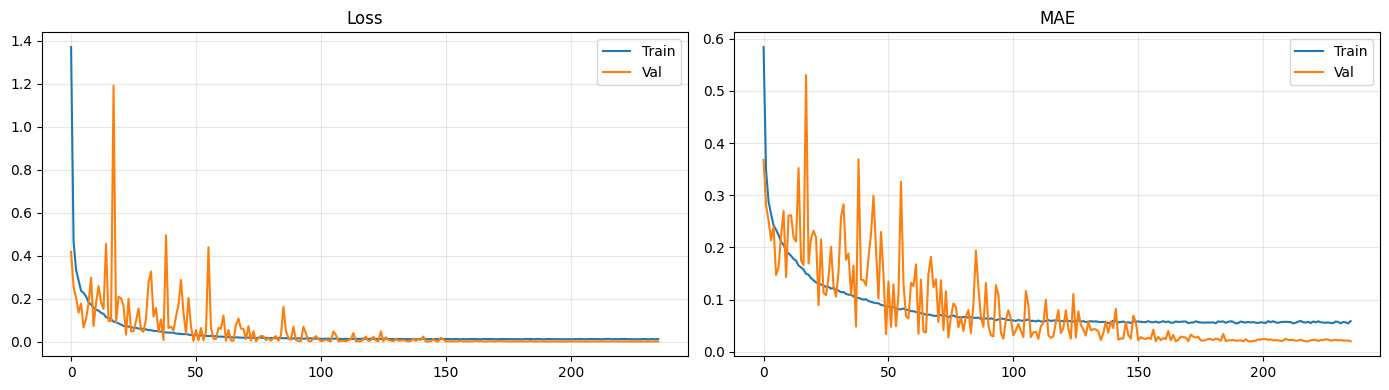


=== Diversity check ===
  Length              : ratio=0.95  ✅
  Diameter            : ratio=0.96  ✅
  Slot_Width          : ratio=0.97  ✅
  Slot_Offset         : ratio=0.98  ✅
  Throat_Diameter     : ratio=0.97  ✅
  Exit_Diameter       : ratio=0.97  ✅

Dimension                   MAE     MAPE       R²
  Length                 1.9809    3.58%   0.9884
  Diameter               0.2412    1.52%   0.9902
  Slot_Width             0.1167    5.16%   0.9706
  Slot_Offset            0.1100    3.66%   0.9915
  Throat_Diameter        0.0151    1.18%   0.9958
  Exit_Diameter          0.0219    1.14%   0.9960


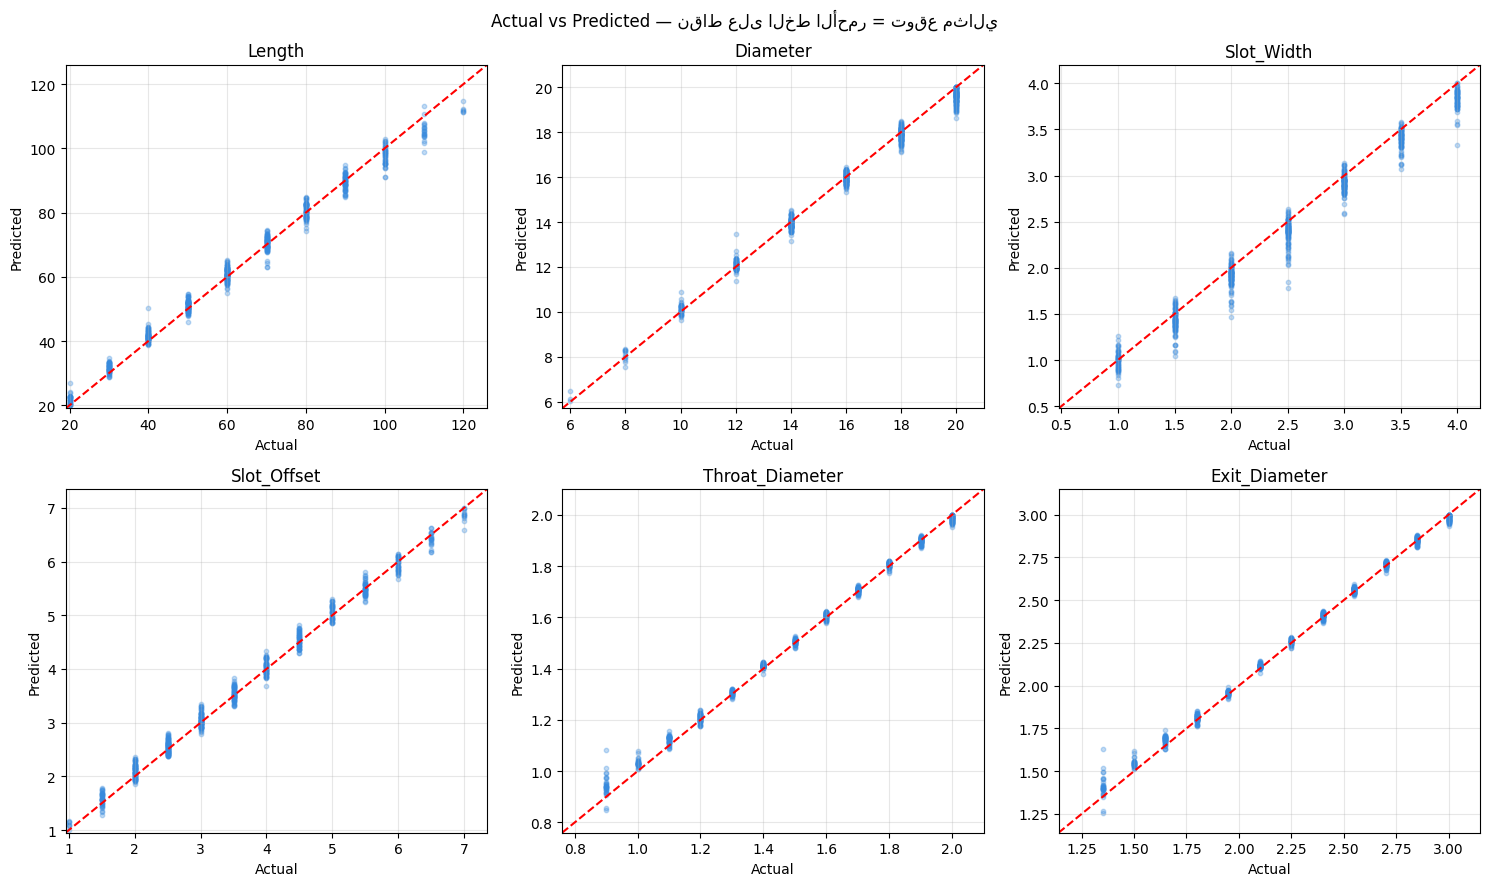

In [32]:
# Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predict + clip
pred_s = c_reverse.predict([Xc_te, Xs_te_s], verbose=0)
y_pred = np.clip(s_Y.inverse_transform(pred_s), BOUNDS_MIN, BOUNDS_MAX)
y_true = Y_te

# Diversity check
print('\n=== Diversity check ===')
for i, name in enumerate(DIM_NAMES):
    ratio = y_pred[:, i].std() / (y_true[:, i].std() + 1e-8)
    flag  = '✅' if ratio > 0.5 else '⚠️  COLLAPSED'
    print(f'  {name:<20}: ratio={ratio:.2f}  {flag}')

# Metrics
print(f"\n{'Dimension':<22} {'MAE':>8} {'MAPE':>8} {'R²':>8}")
print('='*52)
for i, name in enumerate(DIM_NAMES):
    mae  = np.mean(np.abs(y_pred[:,i] - y_true[:,i]))
    mape = np.mean(np.abs((y_pred[:,i]-y_true[:,i])/(y_true[:,i]+1e-8)))*100
    ss_r = np.sum((y_true[:,i]-y_pred[:,i])**2)
    ss_t = np.sum((y_true[:,i]-y_true[:,i].mean())**2)
    r2   = 1 - ss_r/(ss_t+1e-8)
    print(f'  {name:<20} {mae:>8.4f} {mape:>7.2f}% {r2:>8.4f}')

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (name, ax) in enumerate(zip(DIM_NAMES, axes.flat)):
    ax.scatter(y_true[:,i], y_pred[:,i], alpha=0.3, s=10, color='#378ADD')
    lim = [BOUNDS_MIN[i]*0.95, BOUNDS_MAX[i]*1.05]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(name); ax.grid(True, alpha=0.3)
plt.suptitle('Actual vs Predicted — نقاط على الخط الأحمر = توقع مثالي', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 6 — Inference

### الفرق الجوهري عن النسخ السابقة:
الـ ISP **لا يُستخدم** — كل الـ 5 scalars تُحسب من المنحنى مباشرة بنفس المعادلة المستخدمة في الـ training.

In [33]:
def compute_scalars_from_curve(t, thrust, pressure):
    """
    يحسب الـ 5 scalars من المنحنى مباشرة.
    نفس المعادلات الموجودة في الـ training CSV columns.
    """
    max_thrust    = float(np.max(thrust))
    avg_thrust    = float(np.mean(thrust))
    total_impulse = float(trapezoid(thrust, t))
    peak_pressure = float(np.max(pressure))
    burn_time     = float(t[-1] - t[0])
    return [max_thrust, avg_thrust, total_impulse, peak_pressure, burn_time]


def smart_col(df, keywords, exclude=None):
    """يلاقي column اسمه يحتوي على أي keyword من الليستة."""
    exclude = exclude or []
    for col in df.columns:
        cl = col.lower().replace(' ','').replace('_','').replace('(','').replace(')','').replace('/','').replace('.','')
        if any(kw in cl for kw in keywords) and not any(ex in cl for ex in exclude):
            return col
    return None


def predict_file(file_path, actual_dims=None, model=None, num_points=200):
    if model is None:
        model = c_reverse

    s_xs_l = joblib.load('c_rev_scaler_scalars.pkl')
    s_Y_l  = joblib.load('c_rev_scaler_dims.pkl')

    # قراءة الملف
    if file_path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')
    df.columns = df.columns.str.strip()

    # التعرف على الأعمدة
    t_col = smart_col(df, ['time'], exclude=['total','burn'])
    th_col = smart_col(df, ['thrust'], exclude=['max','avg','total','mean'])
    pr_col = smart_col(df, ['pressure'], exclude=['peak','max'])

    if not all([t_col, th_col, pr_col]):
        raise ValueError(
            f'أعمدة ناقصة!\n'
            f'  time={t_col}, thrust={th_col}, pressure={pr_col}\n'
            f'  المتاح: {list(df.columns)}'
        )

    df = df.sort_values(t_col).dropna(subset=[t_col, th_col, pr_col]).reset_index(drop=True)
    t        = df[t_col].values.astype(float)
    thrust   = df[th_col].values.astype(float)
    pressure = df[pr_col].values.astype(float)

    # حساب الـ 5 scalars
    scalars = compute_scalars_from_curve(t, thrust, pressure)

    # Diagnostic
    print(f'\n=== Scalars: {os.path.basename(file_path)} ===')
    centers = s_xs_l.center_
    scales  = s_xs_l.scale_
    all_ok  = True
    for i, (name, val) in enumerate(zip(SCALAR_COLS, scalars)):
        z = (val - centers[i]) / (scales[i] + 1e-8)
        ok = abs(z) < 3
        if not ok: all_ok = False
        print(f'  {name:<25}: {val:>12.3f}  z={z:+.2f}  {"✅" if ok else "⚠️ خارج النطاق"}')
    if all_ok:
        print('  ✅ كل الـ scalars داخل نطاق الـ training')

    # Interpolate + normalize
    x_new = np.linspace(t[0], t[-1], num_points)
    t_i = interp1d(t, thrust,   fill_value='extrapolate')(x_new)
    p_i = interp1d(t, pressure, fill_value='extrapolate')(x_new)
    t_i = t_i / (np.max(np.abs(t_i)) + 1e-8)
    p_i = p_i / (np.max(np.abs(p_i)) + 1e-8)

    curves = np.stack([t_i, p_i], axis=-1).reshape(1, num_points, 2).astype(np.float32)
    scalars_s = s_xs_l.transform([scalars])

    # Predict + clip
    pred_s    = model.predict([curves, scalars_s], verbose=0)
    pred_dims = np.clip(s_Y_l.inverse_transform(pred_s)[0], BOUNDS_MIN, BOUNDS_MAX)

    # عرض
    print(f'\n{"-"*60}')
    print(f"  {'Dimension':<20} {'Predicted':>10}", end='')
    if actual_dims:
        print(f"  {'Actual':>8}  {'Err%':>6}", end='')
    print()
    print(f'{"-"*60}')

    results = {}
    for name, pred, lo, hi in zip(DIM_NAMES, pred_dims, BOUNDS_MIN, BOUNDS_MAX):
        line = f"  {name:<20} {pred:>10.4f}"
        if actual_dims and name in actual_dims:
            actual = actual_dims[name]
            err = abs(pred - actual) / (actual + 1e-8) * 100
            flag = '✅' if err < 10 else ('🟡' if err < 25 else '🔴')
            line += f"  {actual:>8.4f}  {err:>5.1f}%  {flag}"
        print(line)
        results[name] = pred

    print(f'{"-"*60}')
    return results


# ================================================================
# تشغيل على ملفات الـ test مع الأبعاد الحقيقية للمقارنة
# ================================================================
print('=' * 60)
print('TEST 1: 206_0.xlsx')
r1 = predict_file(
    '/kaggle/input/datasets/mohamedesh/c-test-206/206.0.xlsx',
    actual_dims={
        'Length': 20, 'Diameter': 18, 'Slot_Width': 3,
        'Slot_Offset': 2.5, 'Throat_Diameter': 0.8, 'Exit_Diameter': 1.2
    }
)

print()
print('=' * 60)
print('TEST 2: c_test.csv')
r2 = predict_file(
    '/kaggle/input/datasets/mohamedesh/test-c/c_test.csv',
    actual_dims={
        'Length': 100, 'Diameter': 15, 'Slot_Width': 4,
        'Slot_Offset': 4, 'Throat_Diameter': 2, 'Exit_Diameter': 3
    }
)

TEST 1: 206_0.xlsx

=== Scalars: 206.0.xlsx ===
  Max Thrust (N)           :     2382.920  z=-0.33  ✅
  Avg Thrust (N)           :     1257.941  z=-0.39  ✅
  Total Impulse (Ns)       :    14447.454  z=-0.72  ✅
  Peak Pressure (MPa)      :       35.994  z=+1.30  ✅
  Burn Time (s)            :       11.480  z=-0.48  ✅
  ✅ كل الـ scalars داخل نطاق الـ training

------------------------------------------------------------
  Dimension             Predicted    Actual    Err%
------------------------------------------------------------
  Length                  20.0000   20.0000    0.0%  ✅
  Diameter                17.7170   18.0000    1.6%  ✅
  Slot_Width               2.8806    3.0000    4.0%  ✅
  Slot_Offset              2.4950    2.5000    0.2%  ✅
  Throat_Diameter          0.8258    0.8000    3.2%  ✅
  Exit_Diameter            1.2276    1.2000    2.3%  ✅
------------------------------------------------------------

TEST 2: c_test.csv

=== Scalars: c_test.csv ===
  Max Thrust (N)         

## Cell 7 — MC Dropout

In [34]:
def mc_predict(model, curves_in, scalars_in, n_iter=200):
    preds = np.stack([
        model([curves_in, scalars_in], training=True).numpy()
        for _ in range(n_iter)
    ])
    return preds.mean(axis=0), preds.std(axis=0)


def show_mc(sample_idx):
    c_s = Xc_te[sample_idx:sample_idx+1]
    s_s = Xs_te_s[sample_idx:sample_idx+1]
    actual = Y_te[sample_idx]

    mean_s, std_s = mc_predict(c_reverse, c_s, s_s)
    pred = np.clip(s_Y.inverse_transform(mean_s)[0], BOUNDS_MIN, BOUNDS_MAX)
    unc  = std_s[0] / (s_Y.scale_ + 1e-8)

    print(f'\n🎯 MC Dropout — Sample #{sample_idx}')
    print('='*72)
    print(f"{'Dimension':<20} {'Pred':>9} {'±σ':>7} {'Actual':>9} {'Err%':>7} Conf")
    print('='*72)
    for i, name in enumerate(DIM_NAMES):
        err  = abs(pred[i]-actual[i])/(actual[i]+1e-9)*100
        cv   = unc[i]/(abs(pred[i])+1e-9)*100
        conf = '🟢' if cv<5 else ('🟡' if cv<15 else '🔴')
        flag = '✅' if err<10 else ('🟡' if err<25 else '🔴')
        print(f"{name:<20} {pred[i]:>9.3f} {unc[i]:>7.3f} {actual[i]:>9.3f} {err:>6.1f}%  {conf}{flag}")
    print('='*72)


show_mc(0)
show_mc(10)
show_mc(25)


🎯 MC Dropout — Sample #0
Dimension                 Pred      ±σ    Actual    Err% Conf
Length                  62.304   0.534    80.000   22.1%  🟢🟡
Diameter                16.009   0.117    18.000   11.1%  🟢🟡
Slot_Width               2.489   0.026     1.500   65.9%  🟢🔴
Slot_Offset              3.649   0.030     3.000   21.6%  🟢🟡
Throat_Diameter          1.512   0.006     1.500    0.8%  🟢✅
Exit_Diameter            2.269   0.010     2.250    0.8%  🟢✅

🎯 MC Dropout — Sample #10
Dimension                 Pred      ±σ    Actual    Err% Conf
Length                  62.248   0.642   100.000   37.8%  🟢🔴
Diameter                16.003   0.117    10.000   60.0%  🟢🔴
Slot_Width               2.488   0.027     2.500    0.5%  🟢✅
Slot_Offset              3.647   0.031     3.000   21.6%  🟢🟡
Throat_Diameter          1.512   0.008     1.800   16.0%  🟢🟡
Exit_Diameter            2.269   0.011     2.700   16.0%  🟢🟡

🎯 MC Dropout — Sample #25
Dimension                 Pred      ±σ    Actual    Err% Conf
Le